In [1]:
import pandas as pd
import matplotlib.pyplot as plt
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Try loading your data (make sure the path is correct)
df = pd.read_csv("C:/Users/MEGHLA/Downloads/unzip/fraudTrain.csv")
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
import pandas as pd
train_df=pd.read_csv("C:/Users/MEGHLA/Downloads/unzip/fraudTrain.csv")
test_df=pd.read_csv("C:/Users/MEGHLA/Downloads/unzip/fraudTest.csv")
print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Train data shape: (1296675, 23)
Test data shape: (555719, 23)


TRAINING DATA ANALYSIS
Total transactions: 1296675
Fraudulent transactions: 7506
Non-fraudulent transactions: 1289169
Fraud percentage: 0.5789%

class distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


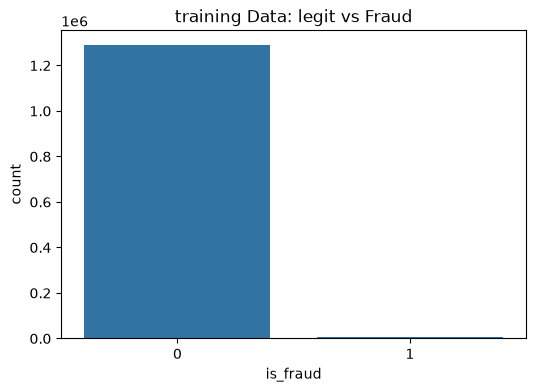

In [4]:
target_col='is_fraud'
print("TRAINING DATA ANALYSIS")
print(f"Total transactions: {len(train_df)}")
print(f"Fraudulent transactions: {train_df[target_col].sum()}")
print(f"Non-fraudulent transactions: {len(train_df) - train_df[target_col].sum()}")
print(f"Fraud percentage: {train_df[target_col].mean() * 100:.4f}%")
print(f"\nclass distribution:")
print(train_df[target_col].value_counts())
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=train_df)
plt.title('training Data: legit vs Fraud')
plt.show()

In [5]:
# importing different models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
print("Models imported successfully!")

Models imported successfully!


In [6]:
#this code should have been done before importing the models, preparing the data for the models
from sklearn.model_selection import train_test_split
X=train_df.drop(columns=[target_col])
y=train_df[target_col]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#scaling the data
from sklearn.preprocessing import StandardScaler
# Dropping the non-numeric columns from the training and validation sets as it was showing error while scaling the data
X_train_clean = X_train.select_dtypes(include=['int64', 'float64'])
X_val_clean = X_val.select_dtypes(include=['int64', 'float64'])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_val_scaled = scaler.transform(X_val_clean)
print("Data prepared for modeling successfully!")

Data prepared for modeling successfully!


In [7]:
#training the models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
}
#result dictionary
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    #calculating metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    #Showing the results
    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    #Storing the results in the dictionary
    results[name] = {'model': model, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1_score': f1}


Logistic Regression:
  Accuracy: 0.9519
  Precision: 0.0861
  Recall: 0.7615
  F1-Score: 0.1548
Decision Tree:
  Accuracy: 0.9051
  Precision: 0.0498
  Recall: 0.8514
  F1-Score: 0.0941
Random Forest:
  Accuracy: 0.9968
  Precision: 0.7818
  Recall: 0.6229
  F1-Score: 0.6934
